In [18]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Single gene-trait association plots

In [20]:
# Configuration and paths
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'
mac = 100

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)
mac
config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()
anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""plof""","""loftee_hc""","""#1f77b4""","""LOFTEE HC""",1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""missense""","""am_pathogenicity""","""#e76e5b""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""conservation""","""gpn_star_llr_calibrated_mean""","""#942c80""","""GPN-Star""",-1
…,…,…,…,…
"""regulatory""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",1
"""regulatory""","""promoterai_under""","""#00A99D""","""PromoterAI under""",-1
"""regulatory""","""promoterai_over""","""#00A99D""","""PromoterAI over""",1


In [71]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_variants_union_annotated_250928.parquet") #.filter(pl.col('gene_name') == gene_name)

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

min_range = -100
max_range = +100

anno = (
    anno
    .filter(
        (pl.col('dist_to_tss') >= min_range) &
        (pl.col('dist_to_tss') <= max_range)
    )
    .select(
        set(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    .drop_nulls()
)

phenotype = anno['region'].unique()[0] + '_olink'
anno

zooverphylop,verphylop,gpn_star_llr_calibrated_mean,abexp_min,gene_length,promoterai_under,delta_score,promoterai,loftee_hc,abexp_max,am_pathogenicity,promoterai_abs,esmscoremissense,TSS,id,promoterai_over,dist_to_tss,relative_cds_position,cadd_raw,pangolin_score,absplice_dna_max,gene_name,region,gpn_score,Strand,absplice2_max
f32,f32,f64,f64,i64,f32,f32,f32,i8,f64,f32,f32,f32,i64,str,f32,i64,f32,f32,f32,f32,str,str,f32,cat,f32
0.935,-0.464,-2.382952,-0.028231,1163126,0.0,0.0,0.0229,0,-0.011976,0.0,0.0229,0.0,212538841,"""chr2:212538763:T:G""",0.0229,78,0.0,0.779811,0.0,0.0,"""ERBB4""","""ENSG00000178568""",-4.08,"""-""",0.0
2.675,0.75,-3.85059,-0.012924,152738,-0.0324,0.0,-0.0324,0,-0.009593,0.0,0.0324,0.0,213152427,"""chr2:213152427:C:A""",0.0,0,0.0,1.10133,0.0,0.0,"""IKZF2""","""ENSG00000030419""",-6.03,"""-""",0.0
0.39,-0.113,-2.115943,-0.003452,152738,0.0,0.0,0.0112,0,-0.000121,0.0,0.0112,0.0,213152427,"""chr2:213152391:G:T""",0.0112,36,0.0,0.244775,0.05,0.0,"""IKZF2""","""ENSG00000030419""",-1.75,"""-""",0.000034
2.333,1.485,-2.334243,-0.001024,8711,0.0,0.0,0.0195,0,-0.000569,0.0,0.0195,0.0,168901290,"""chr2:168901237:G:A""",0.0195,-53,0.0,1.171553,0.0,0.0,"""G6PC2""","""ENSG00000152254""",-3.08,"""+""",0.0
0.038,-0.169,-0.784706,-0.019552,115828,-0.0494,0.0,-0.0494,0,0.011141,0.0,0.0494,0.0,169031324,"""chr2:169031286:G:A""",0.0,38,0.0,0.117705,0.05,0.003,"""ABCB11""","""ENSG00000073734""",-1.18,"""-""",0.000069
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
5.8,4.201,-2.830429,-0.006845,134786,0.0,0.0,0.0156,0,-0.000122,0.0,0.0156,0.0,15112423,"""chr11:15112384:G:A""",0.0156,-39,0.0,2.577645,0.0,0.0,"""INSC""","""ENSG00000188487""",-4.84,"""+""",0.0
-0.252,-0.379,-1.236706,-0.011774,25543,-0.5686,0.0,-0.5686,0,-0.008418,0.0,0.5686,0.0,17351799,"""chr11:17351738:G:A""",0.0,-61,0.0,0.623258,0.0,0.0,"""NCR3LG1""","""ENSG00000188211""",0.31,"""+""",0.0
1.918,0.843,-1.958109,-0.036161,147151,-0.0541,0.08,-0.0541,0,-0.023309,0.0,0.0541,0.0,104928155,"""chr9:104928143:C:G""",0.0,12,0.0,1.970552,0.05,0.0,"""ABCA1""","""ENSG00000165029""",-3.14,"""-""",0.000034


In [72]:
melted_anno = anno.unpivot(
    index=["id", "region"],
    on=existing_annos,
    variable_name="annotation",
    value_name="annotation_score"
).with_columns(
    pl.col("annotation_score").cast(pl.Float32),
    pl.col("region").cast(pl.Utf8),
)
melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr2:212538763:T:G""","""ENSG00000178568""","""loftee_hc""",0.0
"""chr2:213152427:C:A""","""ENSG00000030419""","""loftee_hc""",0.0
"""chr2:213152391:G:T""","""ENSG00000030419""","""loftee_hc""",0.0
"""chr2:168901237:G:A""","""ENSG00000152254""","""loftee_hc""",0.0
"""chr2:169031286:G:A""","""ENSG00000073734""","""loftee_hc""",0.0
…,…,…,…
"""chr11:15112384:G:A""","""ENSG00000188487""","""abexp_max""",-0.000122
"""chr11:17351738:G:A""","""ENSG00000188211""","""abexp_max""",-0.008418
"""chr9:104928143:C:G""","""ENSG00000165029""","""abexp_max""",-0.023309


In [73]:
olink_appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_371olink_rint_corrected90pcs_EUR.parquet")

appv = (
    olink_appv
    .rename({
        'phenotype': 'olink_prot',
        'mean_pheno_value': 'mean_olink_value',
        'std_pheno_value': 'std_olink_value',
    })
    .filter(
        # (pl.col('phenotype') == phenotype) &
        (pl.col('n_individuals') <= mac)
    )
)

appv.head().collect()

id,olink_prot,n_individuals,mean_olink_value,std_olink_value
str,str,u64,f32,f32
"""chr1:3664499:C:T""","""ENSG00000134352_olink""",3,-0.272098,1.556659
"""chr1:3690579:C:T""","""ENSG00000134352_olink""",4,-0.183986,0.678737
"""chr1:3663475:G:T""","""ENSG00000134352_olink""",3,0.647399,1.883861
"""chr1:3706937:G:A""","""ENSG00000134352_olink""",1,-0.580956,null
"""chr1:3678411:G:A""","""ENSG00000134352_olink""",2,-0.301727,null


In [74]:
# Merge phenotype data and annotation data
pg_df = (
    appv
    .join(
        melted_anno.lazy(), 
        on="id", 
        how="inner"
    )
    .filter(
        pl.col('region') + '_olink' == pl.col('olink_prot')
    )
    .join(
        anno.select(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).lazy(), 
        on=['id', 'region'],
        how='inner'
    )
    .collect(engine='streaming')
)

# Join with experimental data
# pg_df = pg_df.join(exp_data.filter(pl.col('gene_name') == gene_name), on='id', how='inner')
pg_df

id,olink_prot,n_individuals,mean_olink_value,std_olink_value,region,annotation,annotation_score,TSS,Strand,gene_length,gene_name,dist_to_tss
str,str,u64,f32,f32,str,str,f32,i64,cat,i64,str,i64
"""chr1:3652518:C:G""","""ENSG00000078900_olink""",1,-0.396097,null,"""ENSG00000078900""","""loftee_hc""",0.0,3652515,"""+""",83687,"""TP73""",3
"""chr1:3652518:C:G""","""ENSG00000078900_olink""",1,-0.396097,null,"""ENSG00000078900""","""cadd_raw""",1.216144,3652515,"""+""",83687,"""TP73""",3
"""chr1:3652518:C:G""","""ENSG00000078900_olink""",1,-0.396097,null,"""ENSG00000078900""","""am_pathogenicity""",0.0,3652515,"""+""",83687,"""TP73""",3
"""chr1:3652518:C:G""","""ENSG00000078900_olink""",1,-0.396097,null,"""ENSG00000078900""","""esmscoremissense""",0.0,3652515,"""+""",83687,"""TP73""",3
"""chr1:3652518:C:G""","""ENSG00000078900_olink""",1,-0.396097,null,"""ENSG00000078900""","""gpn_star_llr_calibrated_mean""",-2.78041,3652515,"""+""",83687,"""TP73""",3
…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr2:65432725:G:A""","""ENSG00000198369_olink""",44,0.045693,0.878483,"""ENSG00000198369""","""promoterai_abs""",0.041,65432637,"""-""",121788,"""SPRED2""",-88
"""chr2:65432725:G:A""","""ENSG00000198369_olink""",44,0.045693,0.878483,"""ENSG00000198369""","""promoterai_under""",-0.041,65432637,"""-""",121788,"""SPRED2""",-88
"""chr2:65432725:G:A""","""ENSG00000198369_olink""",44,0.045693,0.878483,"""ENSG00000198369""","""promoterai_over""",0.0,65432637,"""-""",121788,"""SPRED2""",-88


In [75]:
pg_df['gene_name'].value_counts(sort=True)

gene_name,count
str,u64
"""EGLN1""",1083
"""SNAP29""",1007
"""PREB""",931
"""PKD1""",931
"""NCK2""",912
…,…
"""RGMB""",114
"""LRP1""",114
"""NFIC""",114


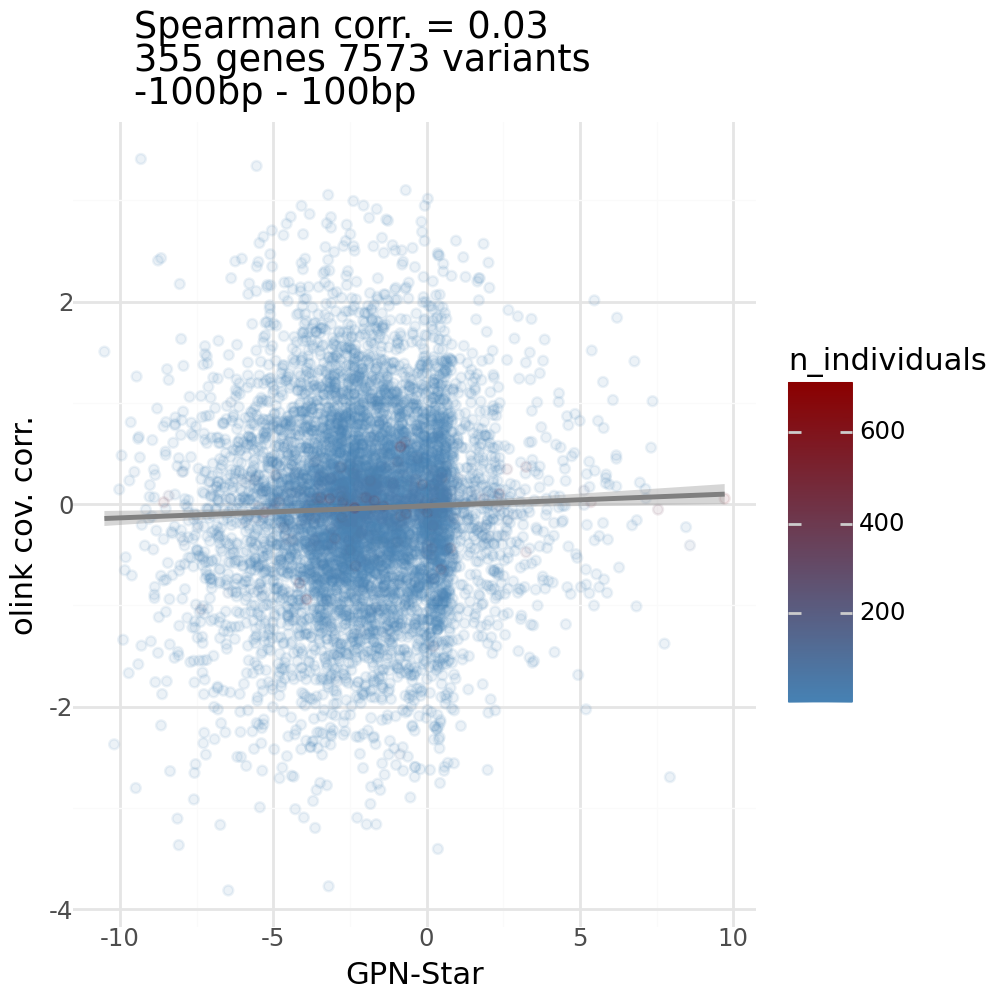

In [82]:
annotation = 'promoterai'
annotation = 'gpn_star_llr_calibrated_mean'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    pg_df
    .filter(
        # (pl.col('gene_name') == gene_name) &
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_olink_value', color='n_individuals')) +
    geom_point(alpha=0.1) +
    geom_smooth(method='glm', se=True, color='gray') +
    scale_color_gradient(low='steelblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"olink cov. corr.",
        title=f"Spearman corr. = {plot_df.select(pl.corr('annotation_score', 'mean_olink_value')).to_series()[0]:.2f} \
        \n{pg_df['gene_name'].n_unique()} genes {plot_df.shape[0]} variants \
        \n{min_range}bp - {max_range}bp"
    ) +
    theme(figure_size=(5, 5))
)

## Average per gene

In [83]:
pg_df

id,olink_prot,n_individuals,mean_olink_value,std_olink_value,region,annotation,annotation_score,TSS,Strand,gene_length,gene_name,dist_to_tss
str,str,u64,f32,f32,str,str,f32,i64,cat,i64,str,i64
"""chr1:3652518:C:G""","""ENSG00000078900_olink""",1,-0.396097,null,"""ENSG00000078900""","""loftee_hc""",0.0,3652515,"""+""",83687,"""TP73""",3
"""chr1:3652518:C:G""","""ENSG00000078900_olink""",1,-0.396097,null,"""ENSG00000078900""","""cadd_raw""",1.216144,3652515,"""+""",83687,"""TP73""",3
"""chr1:3652518:C:G""","""ENSG00000078900_olink""",1,-0.396097,null,"""ENSG00000078900""","""am_pathogenicity""",0.0,3652515,"""+""",83687,"""TP73""",3
"""chr1:3652518:C:G""","""ENSG00000078900_olink""",1,-0.396097,null,"""ENSG00000078900""","""esmscoremissense""",0.0,3652515,"""+""",83687,"""TP73""",3
"""chr1:3652518:C:G""","""ENSG00000078900_olink""",1,-0.396097,null,"""ENSG00000078900""","""gpn_star_llr_calibrated_mean""",-2.78041,3652515,"""+""",83687,"""TP73""",3
…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr2:65432725:G:A""","""ENSG00000198369_olink""",44,0.045693,0.878483,"""ENSG00000198369""","""promoterai_abs""",0.041,65432637,"""-""",121788,"""SPRED2""",-88
"""chr2:65432725:G:A""","""ENSG00000198369_olink""",44,0.045693,0.878483,"""ENSG00000198369""","""promoterai_under""",-0.041,65432637,"""-""",121788,"""SPRED2""",-88
"""chr2:65432725:G:A""","""ENSG00000198369_olink""",44,0.045693,0.878483,"""ENSG00000198369""","""promoterai_over""",0.0,65432637,"""-""",121788,"""SPRED2""",-88
